In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


In [15]:
import os
from PIL import Image

folders = [
    'data/train/burned',
    'data/train/not_burned',
    'data/val/burned',
    'data/val/not_burned'
]

removed = 0
for folder in folders:
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            img.verify()  # checks if image is intact
        except Exception:
            print(f"Removing corrupted file: {fpath}")
            os.remove(fpath)
            removed += 1

print(f"\nDone. Removed {removed} corrupted files.")


Done. Removed 0 corrupted files.


In [16]:
def count_images(folder):
    exts = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
    return sum(f.lower().endswith(exts) for _, _, files in os.walk(folder) for f in files)

print(f"Train burned     : {count_images('data/train/burned')}")
print(f"Train not_burned : {count_images('data/train/not_burned')}")
print(f"Val burned       : {count_images('data/val/burned')}")
print(f"Val not_burned   : {count_images('data/val/not_burned')}")

Train burned     : 10866
Train not_burned : 14500
Val burned       : 3480
Val not_burned   : 2820


In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True, seed=42
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

# Must be: {'burned': 0, 'not_burned': 1}
print("Class indices:", train_gen.class_indices)

Found 25366 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Class indices: {'burned': 0, 'not_burned': 1}


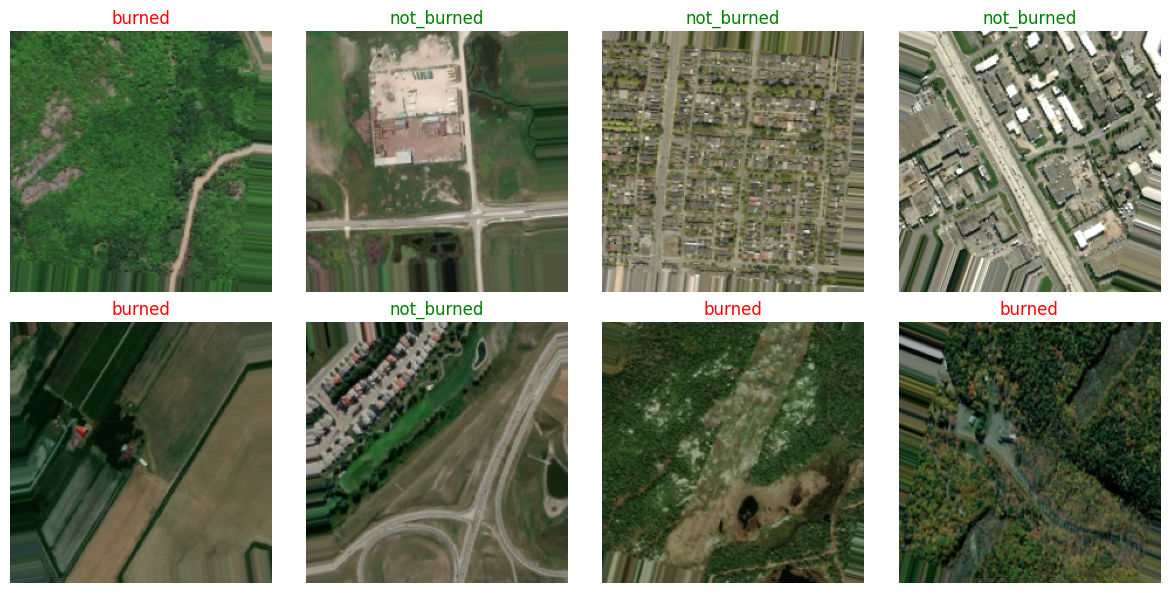

In [18]:
images, labels = next(train_gen)
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(['burned','not_burned'][int(labels[i])],
               color='red' if labels[i]==0 else 'green')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [20]:
def build_model():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model, base

model, base_model = build_model()
print("Model ready.")

Model ready.


In [21]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history1 = model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks, verbose=1
)

Epoch 1/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8619 - loss: 0.3152
Epoch 1: val_accuracy improved from None to 0.94349, saving model to model/burned_area_model.h5


793/793 ━━━━━━━━━━━━━━━━━━━━ 401s 502ms/step - accuracy: 0.9036 - loss: 0.2425 - val_accuracy: 0.9435 - val_loss: 0.1556 - learning_rate: 1.0000e-04
Epoch 2/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9295 - loss: 0.1892
Epoch 2: val_accuracy improved from 0.94349 to 0.94603, saving model to model/burned_area_model.h5


793/793 ━━━━━━━━━━━━━━━━━━━━ 399s 503ms/step - accuracy: 0.9342 - loss: 0.1779 - val_accuracy: 0.9460 - val_loss: 0.1541 - learning_rate: 1.0000e-04
Epoch 3/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9357 - loss: 0.1700
Epoch 3: val_accuracy improved from 0.94603 to 0.95143, saving model to model/burned_area_model.h5


793/793 ━━━━━━━━━━━━━━━━━━━━ 371s 467ms/step - accuracy: 0.9365 - loss: 0.1674 - val_accuracy: 0.9514 - val_loss: 0.1354 - learning_rate: 1.0000e-04
Epoch 4/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9412 - loss: 0.1571
Epoch 4: val_accuracy improved from 0.95143 to 0.95444, saving model to model/burned_area_model.h5


793/793 ━━━━━━━━━━━━━━━━━━━━ 381s 481ms/step - accuracy: 0.9422 - loss: 0.1552 - val_accuracy: 0.9544 - val_loss: 0.1208 - learning_rate: 1.0000e-04
Epoch 5/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9455 - loss: 0.1510
Epoch 5: val_accuracy improved from 0.95444 to 0.95476, saving model to model/burned_area_model.h5


...

793/793 ━━━━━━━━━━━━━━━━━━━━ 369s 465ms/step - accuracy: 0.9516 - loss: 0.1283 - val_accuracy: 0.9575 - val_loss: 0.1152 - learning_rate: 5.0000e-05
Epoch 11/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9506 - loss: 0.1281
Epoch 11: val_accuracy did not improve from 0.95746
793/793 ━━━━━━━━━━━━━━━━━━━━ 366s 461ms/step - accuracy: 0.9520 - loss: 0.1248 - val_accuracy: 0.9560 - val_loss: 0.1203 - learning_rate: 5.0000e-05
Epoch 12/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9510 - loss: 0.1243
Epoch 12: val_accuracy improved from 0.95746 to 0.95762, saving model to model/burned_area_model.h5


793/793 ━━━━━━━━━━━━━━━━━━━━ 367s 463ms/step - accuracy: 0.9524 - loss: 0.1237 - val_accuracy: 0.9576 - val_loss: 0.1129 - learning_rate: 5.0000e-05
Epoch 13/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9528 - loss: 0.1181
Epoch 13: val_accuracy improved from 0.95762 to 0.96048, saving model to model/burned_area_model.h5


793/793 ━━━━━━━━━━━━━━━━━━━━ 367s 463ms/step - accuracy: 0.9523 - loss: 0.1209 - val_accuracy: 0.9605 - val_loss: 0.1081 - learning_rate: 5.0000e-05
Epoch 14/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9531 - loss: 0.1224
Epoch 14: val_accuracy did not improve from 0.96048
793/793 ━━━━━━━━━━━━━━━━━━━━ 367s 462ms/step - accuracy: 0.9536 - loss: 0.1217 - val_accuracy: 0.9573 - val_loss: 0.1163 - learning_rate: 5.0000e-05
Epoch 15/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9557 - loss: 0.1159
Epoch 15: val_accuracy did not improve from 0.96048
793/793 ━━━━━━━━━━━━━━━━━━━━ 368s 465ms/step - accuracy: 0.9559 - loss: 0.1176 - val_accuracy: 0.9567 - val_loss: 0.1166 - learning_rate: 5.0000e-05
Epoch 16/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9575 - loss: 0.1129
Epoch 16: val_accuracy improved from 0.96048 to 0.96206, saving model to model/burned_area_model.h5


793/793 ━━━━━━━━━━━━━━━━━━━━ 368s 464ms/step - accuracy: 0.9564 - loss: 0.1133 - val_accuracy: 0.9621 - val_loss: 0.1059 - learning_rate: 5.0000e-05
Epoch 17/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9552 - loss: 0.1151
Epoch 17: val_accuracy did not improve from 0.96206
793/793 ━━━━━━━━━━━━━━━━━━━━ 367s 462ms/step - accuracy: 0.9552 - loss: 0.1154 - val_accuracy: 0.9573 - val_loss: 0.1163 - learning_rate: 5.0000e-05
Epoch 18/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9565 - loss: 0.1171
Epoch 18: val_accuracy did not improve from 0.96206
793/793 ━━━━━━━━━━━━━━━━━━━━ 365s 460ms/step - accuracy: 0.9567 - loss: 0.1150 - val_accuracy: 0.9613 - val_loss: 0.1040 - learning_rate: 5.0000e-05
Epoch 19/30
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9578 - loss: 0.1100
Epoch 19: val_accuracy did not improve from 0.96206
793/793 ━━━━━━━━━━━━━━━━━━━━ 400s 505ms/step - accuracy: 0.9562 - loss: 0.1136 - val_accuracy: 0.9578 - val_loss: 0.1163 - learnin

KeyboardInterrupt: 

197/197 ━━━━━━━━━━━━━━━━━━━━ 52s 258ms/step - accuracy: 0.9621 - loss: 0.1059

Val Accuracy: 96.21%
197/197 ━━━━━━━━━━━━━━━━━━━━ 52s 255ms/step
              precision    recall  f1-score   support

      burned       0.98      0.95      0.97      3480
  not_burned       0.94      0.97      0.96      2820

    accuracy                           0.96      6300
   macro avg       0.96      0.96      0.96      6300
weighted avg       0.96      0.96      0.96      6300



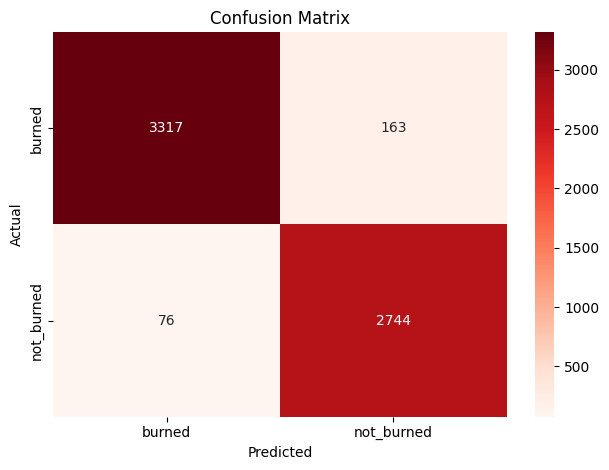

In [24]:
best_model = load_model(MODEL_PATH)
loss, acc  = best_model.evaluate(val_gen, verbose=1)
print(f"\nVal Accuracy: {acc*100:.2f}%")

val_gen.reset()
preds  = (best_model.predict(val_gen, verbose=1) > 0.5).astype(int).flatten()
labels = val_gen.classes

print(classification_report(labels, preds, target_names=['burned','not_burned']))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['burned','not_burned'],
            yticklabels=['burned','not_burned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()